# Taller: Support Vector Machines (SVM)


### Aprendizaje Supervisado — Clasificación con Margen Máximo




**Pontificia Universidad Católica del Ecuador · Carrera de Ingeniería de Sistemas de Información**

**Asignatura:** Inteligencia Artificial · Sexto Semestre

**Nombre del estudiante:** Paúl Rosero

**Fecha:** 02-10-2026

> **Cómo usar este material:** este taller se entrega como página de referencia (HTML), no es un notebook
> interactivo. Reproduce cada celda de código en tu propio Google Colab o Jupyter Notebook, en el mismo
> orden en que aparecen — cada bloque depende de los objetos creados en el anterior. Solo necesitas tu
> propio notebook y el archivo `fraude_tarjetas_ecuador.csv`.


## Objetivos del taller



Al finalizar este taller el estudiante será capaz de:

1. Preparar los datos para SVM con `ColumnTransformer` (One-Hot Encoding + escalado).
2. Entrenar modelos `SVC` con kernel **lineal** y **RBF** dentro de un `Pipeline`.
3. Usar `class_weight='balanced'` para detectar más fraudes en un dataset desbalanceado.
4. Analizar el efecto del hiperparámetro **C**.
5. Reentrenar el modelo final con el 100% de los datos, exportarlo con `joblib` y usarlo con datos nuevos.


## Dataset



**Archivo:** `fraude_tarjetas_ecuador.csv` — 2 000 transacciones con tarjeta de crédito (dataset sintético, sin valores nulos).

| Variable | Tipo | Descripción |
| --- | --- | --- |
| `monto_usd` | Numérica | Monto de la transacción en USD (10 a 1 234) |
| `hora` | Numérica | Hora del día (0 a 23) |
| `tipo_comercio` | Categórica | Supermercado / Restaurante / Electronica / Farmacia / Gasolinera / Viajes |
| `dispositivo` | Categórica | tarjeta_fisica / app_movil / web |
| `historial_fraude` | Binaria (0/1) | 1 = el titular tiene antecedentes de fraude |
| `fraude` | Objetivo (y) | 1 = fraudulenta · 0 = legítima |


## Estructura del taller



| Bloque | Tipo | Contenido |
| --- | --- | --- |
| A1 | Guiado | Carga y exploración |
| A2 | Guiado | Preparación de datos: X, y, división y `ColumnTransformer` |
| A3 | Guiado | SVM con kernel lineal |
| A4 | Guiado | SVM con kernel RBF |
| A5 | Guiado | Clases desbalanceadas: `class_weight='balanced'` |
| A6 | Guiado | Predicción de una transacción nueva |
| B1 | Autónomo | Efecto del hiperparámetro C |
| B2 | Autónomo | Predicción de un segundo caso |
| C | Guiado | Entrenamiento final (100%), exportación y uso con datos nuevos |



## Rúbrica de evaluación (10 puntos)



| Componente | Qué se evalúa | Puntos |
| --- | --- | --- |
| Bloques A1–A6 y C (guiados) | Reproducidos completos y sin errores en tu notebook | 1.5 |
| B1 — código | Tres modelos con C = 0.1, 1 y 10 entrenados y evaluados correctamente | 2.5 |
| B1 — análisis | Tabla completa y respuestas justificadas con tus resultados | 2.5 |
| B2 — código | Transacción construida y predicha correctamente con el Pipeline | 1.5 |
| B2 — análisis | Respuestas justificadas | 2.0 |
| **Total** |  | **10.0** |

**Instrucción:** reproduce cada bloque en tu propio Colab/Jupyter, en orden. No saltes bloques.


# Parte A — Laboratorio Guiado


## Bloque A1 · Carga y exploración



**Librerías que usamos:** `pandas` (datos) y `matplotlib.pyplot` (gráficos).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fraude_tarjetas_ecuador.csv')
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Filas: 2000 | Columnas: 6


,monto_usd,hora,tipo_comercio,dispositivo,historial_fraude,fraude
0,234.42,6,Supermercado,app_movil,0,0
1,87.96,19,Gasolinera,tarjeta_fisica,1,0
2,148.14,14,Electronica,web,0,1
3,160.17,10,Gasolinera,app_movil,0,0
4,79.99,7,Restaurante,tarjeta_fisica,0,0


In [3]:
# Tipos de datos y valores nulos
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   monto_usd         2000 non-null   float64
 1   hora              2000 non-null   int64  
 2   tipo_comercio     2000 non-null   object 
 3   dispositivo       2000 non-null   object 
 4   historial_fraude  2000 non-null   int64  
 5   fraude            2000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 93.9+ KB


**¿Cuántos fraudes hay?** La proporción de clases cambia cómo interpretamos las métricas.


fraude
0    1426
1     574
Name: count, dtype: int64

fraude
0    71.3
1    28.7
Name: proportion, dtype: float64


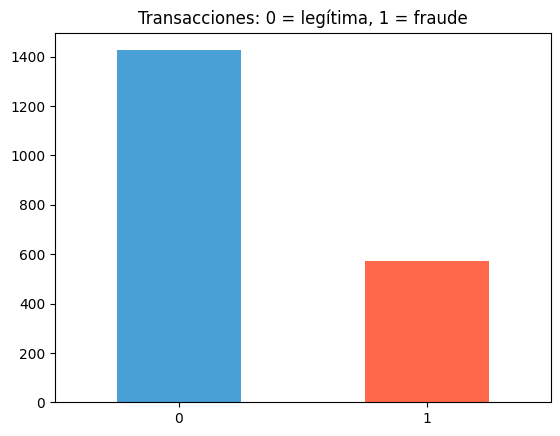

In [4]:
conteo = df['fraude'].value_counts()
print(conteo)
print()
print((df['fraude'].value_counts(normalize=True) * 100).round(1))

ax = conteo.plot(kind='bar', color=['#49A0D6', '#FF6849'])
ax.set_title('Transacciones: 0 = legítima, 1 = fraude')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.show()


**Observación:** hay 71% de transacciones legítimas y 29% de fraudes. Un modelo que siempre diga
"legítima" tendría 71% de Accuracy sin detectar ningún fraude. Por eso miraremos el **Recall de fraude**.


historial_fraude
0    19.2
1    55.8
Name: fraude, dtype: float64


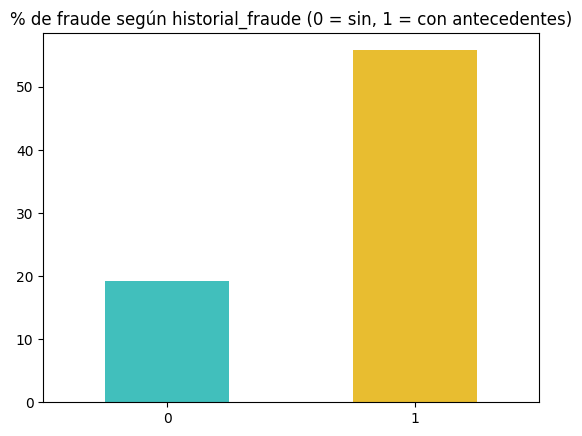

In [5]:
# % de fraude según si el titular tiene antecedentes
tasa = df.groupby('historial_fraude')['fraude'].mean() * 100
print(tasa.round(1))

ax = tasa.plot(kind='bar', color=['#41BFBC', '#E8BD30'])
ax.set_title('% de fraude según historial_fraude (0 = sin, 1 = con antecedentes)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.show()


## Bloque A2 · Preparación de los datos



**Librerías que usamos:** `train_test_split`, `ColumnTransformer`, `OneHotEncoder`, `StandardScaler`.

**¿Por qué escalar es obligatorio en SVM?** SVM calcula distancias entre puntos. `monto_usd` varía
unas 20 veces más que `hora`; sin escalar, la hora casi no influiría en el margen.

**¿Por qué `stratify=y`?** Mantiene la misma proporción de fraudes (≈ 28.7%) en entrenamiento y en prueba.
Sin él, una división al azar podría dejar menos fraudes en uno de los dos conjuntos.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. X: las 5 variables predictoras  ·  y: la columna objetivo
X = df.drop('fraude', axis=1)
y = df['fraude']

# 2. División 80/20 manteniendo la proporción de fraudes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape[0]} filas | % fraude: {y_train.mean() * 100:.1f}%")
print(f"Prueba:        {X_test.shape[0]} filas | % fraude: {y_test.mean() * 100:.1f}%")


Entrenamiento: 1600 filas | % fraude: 28.7%
Prueba:        400 filas | % fraude: 28.7%


**`ColumnTransformer`** aplica One-Hot Encoding a las variables categóricas y `StandardScaler` a las
numéricas, en un solo objeto. Todavía **no** se entrena aquí: se ajustará dentro de cada `Pipeline`,
solo con `X_train`, cuando llamemos a `fit()`.


In [7]:
cat_cols = ['tipo_comercio', 'dispositivo']
num_cols = ['monto_usd', 'hora', 'historial_fraude']

preproc = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])
print("preproc listo.")


preproc listo.


## Bloque A3 · SVM con kernel lineal



**Librerías que usamos:** `Pipeline`, `SVC`, `classification_report`, `ConfusionMatrixDisplay`.

`SVC(kernel='linear')` busca una frontera **recta** con el mayor margen posible. Es el primer modelo
recomendado. Usamos `C=1.0`, el valor por defecto.

El `Pipeline` une `preproc` y el modelo: `fit()` escala y entrena; `predict()` escala y predice.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

pipe_lineal = Pipeline([
    ('preproc', preproc),
    ('modelo', SVC(kernel='linear', C=1.0)),
])
pipe_lineal.fit(X_train, y_train)
y_pred_lineal = pipe_lineal.predict(X_test)
print("Modelo lineal entrenado.")


Modelo lineal entrenado.


              precision    recall  f1-score   support

    Legítima       0.80      0.80      0.80       285
      Fraude       0.51      0.51      0.51       115

    accuracy                           0.72       400
   macro avg       0.66      0.66      0.66       400
weighted avg       0.72      0.72      0.72       400



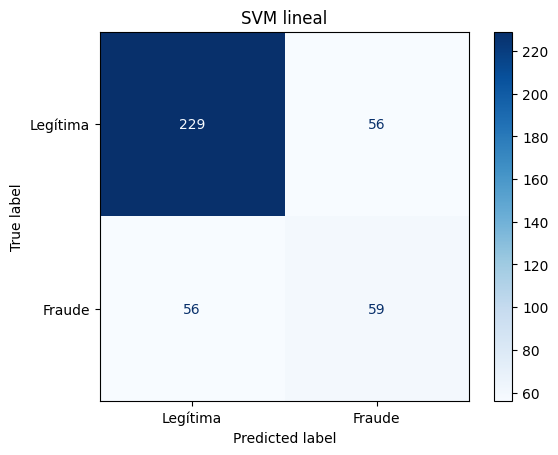

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred_lineal, target_names=['Legítima', 'Fraude']))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lineal, display_labels=['Legítima', 'Fraude'], cmap='Blues')
plt.title('SVM lineal')
plt.show()


**Cómo leer el reporte** (todas las métricas van de 0 a 1 → 1 = deseado):

* **Recall de Fraude:** de cada 100 fraudes reales, cuántos detecta el modelo.
* **Precision de Fraude:** de cada 100 alertas de fraude, cuántas son fraudes reales.


## Bloque A4 · SVM con kernel RBF



El kernel **RBF** (Radial Basis Function) permite fronteras curvas. Es el kernel por defecto de `SVC`.
Usamos sus valores por defecto: `C=1.0` y `gamma='scale'` (scikit-learn calcula gamma a partir del
número de variables y de su varianza).

**`n_support_`** no es un parámetro: es un **atributo** que solo existe después de `fit()`. Indica cuántos
vectores de soporte encontró el modelo en cada clase. Para leerlo dentro de un Pipeline usamos
`named_steps['modelo']`.


In [10]:
pipe_rbf = Pipeline([
    ('preproc', preproc),
    ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale')),
])
pipe_rbf.fit(X_train, y_train)
y_pred_rbf = pipe_rbf.predict(X_test)

print(classification_report(y_test, y_pred_rbf, target_names=['Legítima', 'Fraude']))
print("Vectores de soporte [legítima, fraude]:", pipe_rbf.named_steps['modelo'].n_support_)


              precision    recall  f1-score   support

    Legítima       0.78      0.88      0.83       285
      Fraude       0.56      0.37      0.44       115

    accuracy                           0.73       400
   macro avg       0.67      0.62      0.63       400
weighted avg       0.71      0.73      0.72       400

Vectores de soporte [legítima, fraude]: [458 414]


**Observa:** el modelo RBF tiene un Accuracy parecido o mayor que el lineal, pero su **Recall de
Fraude es menor**: deja pasar más fraudes. Además, cerca de la mitad de las transacciones de
entrenamiento son vectores de soporte: las dos clases están muy mezcladas.


## Bloque A5 · Clases desbalanceadas: `class_weight='balanced'`



Con 71% de legítimas, el modelo tiende a favorecer la clase mayoritaria. `class_weight='balanced'`
da más peso a los errores en la clase minoritaria:

**peso de una clase = n_total / (k × n_clase)**, donde k = número de clases (aquí 2).

* Legítima: 2000 / (2 · 1426) = **0.70**
* Fraude: 2000 / (2 · 574) = **1.74** → cada error en un fraude pesa ≈ 2.5 veces más.

Entrenamos los dos kernels otra vez, ahora balanceados. **Lo único que cambia es el paso `'modelo'`.**


In [11]:
pipe_lineal_bal = Pipeline([
    ('preproc', preproc),
    ('modelo', SVC(kernel='linear', C=1.0, class_weight='balanced')),
])
pipe_rbf_bal = Pipeline([
    ('preproc', preproc),
    ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')),
])

pipe_lineal_bal.fit(X_train, y_train)
pipe_rbf_bal.fit(X_train, y_train)
y_pred_lineal_bal = pipe_lineal_bal.predict(X_test)
y_pred_rbf_bal = pipe_rbf_bal.predict(X_test)
print("Modelos balanceados entrenados.")


Modelos balanceados entrenados.


**Comparación de los 4 modelos** (métricas de la clase Fraude; rango 0 a 1 → 1 = deseado):


In [12]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

predicciones = [y_pred_lineal, y_pred_rbf, y_pred_lineal_bal, y_pred_rbf_bal]

resultados = pd.DataFrame({
    'Modelo': ['Lineal', 'RBF', 'Lineal + balanced', 'RBF + balanced'],
    'Accuracy': [accuracy_score(y_test, p) for p in predicciones],
    'Recall fraude': [recall_score(y_test, p) for p in predicciones],
    'F1 fraude': [f1_score(y_test, p) for p in predicciones],
})
resultados.round(3)


,Modelo,Accuracy,Recall fraude,F1 fraude
0,Lineal,0.720,0.513,0.513
1,RBF,0.735,0.365,0.442
2,Lineal + balanced,0.675,0.652,0.536
3,RBF + balanced,0.662,0.617,0.513


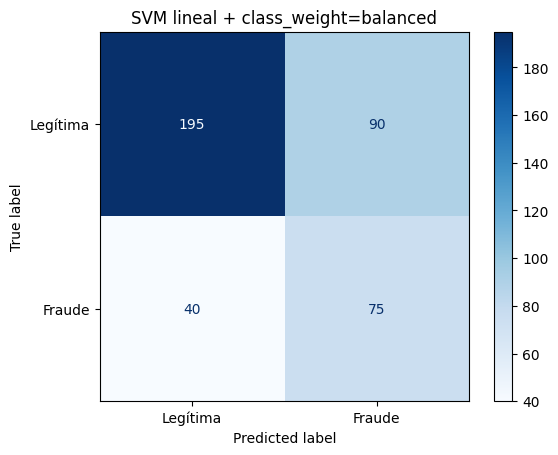

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lineal_bal, display_labels=['Legítima', 'Fraude'], cmap='Blues')
plt.title('SVM lineal + class_weight=balanced')
plt.show()


**Conclusiones:**

* El modelo con **mayor Accuracy no es el que más fraudes detecta**: Accuracy no basta en datos desbalanceados.
* `class_weight='balanced'` sube claramente el Recall de fraude en ambos kernels (a cambio de más falsas alarmas).
* En este dataset el kernel lineal balanceado iguala o supera al RBF: **más complejo no siempre es mejor**.
  Por eso lo elegimos como modelo final (Bloque C).


## Bloque A6 · Predicción de una transacción nueva



Gracias al `Pipeline`, basta con crear un DataFrame con los datos **crudos** (las mismas 5 columnas de `X`)
y llamar a `predict()`: la codificación y el escalado se aplican por dentro, con lo aprendido en el entrenamiento.

> ⚠ **No uses `pd.get_dummies` sobre una sola fila nueva:** con una sola transacción genera columnas
> distintas a las del entrenamiento y la predicción sale mal sin dar error. El Pipeline evita este problema.

**Transacción:** $850 · 2 a. m. · Electronica · web · con antecedentes de fraude.


In [14]:
nueva = pd.DataFrame({
    'monto_usd': [850.0],
    'hora': [2],
    'tipo_comercio': ['Electronica'],
    'dispositivo': ['web'],
    'historial_fraude': [1],
})

pred = pipe_lineal_bal.predict(nueva)
distancia = pipe_lineal_bal.decision_function(nueva)

print("Predicción:", 'FRAUDE' if pred[0] == 1 else 'LEGÍTIMA')
print(f"decision_function: {distancia[0]:.2f}  (positivo → fraude; más lejos de 0 → más seguro)")


Predicción: FRAUDE
decision_function: 3.00  (positivo → fraude; más lejos de 0 → más seguro)


**Nota:** `SVC` no tiene `predict_proba()` por defecto. `decision_function()` devuelve la distancia con
signo al hiperplano: un valor positivo significa fraude y uno negativo, legítima.


# Parte B — Práctica Autónoma



En **tu propio notebook**, escribe el código que reemplace cada `# TODO` que ves en esta guía y responde las
preguntas en una celda de texto. Usa los objetos de la Parte A (`preproc`, `X_train`, `y_train`, ...).


## Bloque B1 · Efecto del hiperparámetro C



**Recuerda:** C bajo → margen amplio, tolera errores · C alto → margen estrecho, castiga errores.

**Tu tarea:** entrenar tres pipelines con kernel RBF y `class_weight='balanced'`, cambiando solo C:
`C = 0.1`, `C = 1.0` y `C = 10.0`. Para cada uno, calcula Accuracy, Recall de fraude, F1 de fraude y
el total de vectores de soporte.


In [21]:
# TODO 1: pipeline con C = 0.1 (copia pipe_rbf_bal del Bloque A5 y cambia solo C)
pipe_c01 = Pipeline([('preproc', preproc),
                    ('modelo', SVC(kernel='rbf', C=0.1, gamma='scale', class_weight='balanced'))])
pipe_c01.fit(X_train, y_train)
y_pred_c01 = pipe_c01.predict(X_test)

# TODO 2: repite para C = 1.0 (pipe_c1) y C = 10.0 (pipe_c10)
pipe_c1 = Pipeline([('preproc', preproc),
                    ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced'))])
pipe_c1.fit(X_train, y_train)
y_pred_c1 = pipe_c1.predict(X_test)

pipe_c10 = Pipeline([('preproc', preproc),
                    ('modelo', SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced'))])
pipe_c10.fit(X_train, y_train)
y_pred_c10 = pipe_c10.predict(X_test)


In [24]:
# TODO 3: tabla comparativa (mismo estilo que el Bloque A5)
predicciones_c = [y_pred_c01, y_pred_c1, y_pred_c10]
tabla_c = pd.DataFrame({
    'C': [0.1, 1.0, 10.0],
    'Accuracy': [accuracy_score(y_test, p) for p in predicciones_c],
    'Recall fraude': [recall_score(y_test, p) for p in predicciones_c],
    'F1 fraude': [f1_score(y_test, p) for p in predicciones_c],
    'Vectores de soporte': [
        pipe_c01.named_steps['modelo'].n_support_.sum(),
        pipe_c1.named_steps['modelo'].n_support_.sum(),
        pipe_c10.named_steps['modelo'].n_support_.sum()
    ],
})
tabla_c.round(3)

,C,Accuracy,Recall fraude,F1 fraude,Vectores de soporte
0,0.1,0.715,0.557,0.529,1173
1,1.0,0.662,0.617,0.513,1074
2,10.0,0.665,0.652,0.528,1010


**Completa la tabla con tus resultados:**

| C | Accuracy | Recall fraude | F1 fraude | Vectores de soporte |
| --- | --- | --- | --- | --- |
| 0.1 | 0.715 | 0.557 | 0.529 | 1173 |
| 1.0 | 0.662 | 0.617 | 0.513 | 1074 |
| 10.0 | 0.665 | 0.652 | 0.528 | 1010 |

**Preguntas:**

1. ¿Qué pasa con el número de vectores de soporte cuando C aumenta? Explícalo con la idea de margen amplio vs. estrecho.  
   Cuando C aumenta, el número de vectores de soporte disminuye, esto ocurre porque un valor menor de C permite un margen más amplio y tolera más puntos dentro o fuera de este, convirtiéndolos en vectores de soporte. Al contrario, un C más alto impone un margen estrecho que penaliza estrictamente las violaciones, dejando que menos puntos definan la frontera.

2. ¿Qué valor de C da el mayor Recall de fraude? ¿Y el mayor Accuracy? ¿Coinciden?  
   El mayor Recall de fraude lo da C = 10.0 que da 0.652, mientras que el mayor Accuracy se obtiene con C = 0.1 quien da 0.715. No coinciden, ya que al priorizar la detección de la clase minoritaria, se incrementan las falsas alarmas, disminuyendo la precisión general del modelo.

3. ¿Alguno de los tres modelos RBF supera al modelo **lineal + balanced** del Bloque A5 en Recall y F1 de fraude?  
   Ninguno de los modelos RBF supera integralmente al modelo lineal balanceado del Bloque A5, el cual tiene un Recall de 0.652 y un F1 de 0.536. El modelo RBF con C = 10.0 iguala su Recall de 0.652 pero obtiene un F1-score ligeramente inferior de 0.528, lo que hace que el modelo lineal siga siendo la mejor alternativa.

4. En un banco real, ¿qué es más costoso: un fraude no detectado o una falsa alarma? ¿Qué métrica priorizarías?  
   Un fraude no detectado es infinitamente más costoso debido a la pérdida financiera directa y al impacto reputacional para el banco. Una falsa alarma solo requiere una verificación adicional sencilla y de bajo costo operativo. Por ello, se debe priorizar la métrica de Recall para capturar la mayor cantidad posible de fraudes.

## Bloque B2 · Predicción de un segundo caso



**Tu tarea:** predecir con `pipe_lineal_bal` (Bloque A5) si esta transacción es fraude:

| Variable | Valor |
| --- | --- |
| `monto_usd` | 45.0 |
| `hora` | 12 |
| `tipo_comercio` | Restaurante |
| `dispositivo` | tarjeta_fisica |
| `historial_fraude` | 0 |


In [26]:
# TODO 1: crear el DataFrame con los valores de la tabla (mismo formato que en el Bloque A6)
nueva_b = pd.DataFrame({'monto_usd': [45.0], 'hora': [12], 'tipo_comercio': ['Restaurante'],
                       'dispositivo': ['tarjeta_fisica'], 'historial_fraude': [0]})

# TODO 2: predecir con pipe_lineal_bal y mostrar FRAUDE o LEGÍTIMA, y el valor de decision_function
pred_lineal = pipe_lineal_bal.predict(nueva_b)
distancia = pipe_lineal_bal.decision_function(nueva_b)

print("Predicción:", 'FRAUDE' if pred_lineal[0] == 1 else 'LEGÍTIMA')
print(f"decision_function: {distancia[0]:.2f}")


Predicción: LEGÍTIMA
decision_function: -1.00


**Preguntas:**

1. ¿Qué predijo el modelo? ¿Era lo que esperabas? Justifica con las características de la transacción.  
   El modelo predijo que la transacción es LEGÍTIMA. Esto era de esperarse debido a que todas las características presentan patrones de bajo riesgo financiero: un monto muy bajo de tan solo $45.0 USD, realizada en una hora de actividad normal, de manera presencial con tarjeta física en un restaurante, y sin que el cliente posea antecedentes de fraude en el sistema.

2. Compara su `decision_function` con la de la transacción del Bloque A6. ¿Cuál de las dos está más lejos del hiperplano?  
   La transacción del Bloque A6 tiene un score de +3.00, mientras que la transacción actual tiene -1.00. Por lo tanto, la transacción del Bloque A6 se encuentra más lejos del hiperplano, lo que indica que el modelo clasifica con mucha mayor certeza la transacción de fraude del Bloque A6 que la legitimidad del caso actual.

3. ¿Qué variables explican que ambas transacciones se clasifiquen distinto? (Pista: revisa los gráficos del Bloque A1.)  
   Las diferencias clave radican principalmente en el monto económico y el historial del cliente, puesto que la presencia de antecedentes de fraude eleva el riesgo significativamente según la exploración de datos. Además, el canal y la hora actúan como factores críticos de separación.

# Bloque C — Entrenamiento Final, Exportación y Uso con Datos Nuevos



**Idea central:** el split 80/20 sirvió para **medir** qué tan bien generaliza cada modelo. Una vez elegido
el modelo (**kernel lineal + `class_weight='balanced'`**, el de mayor Recall y F1 de fraude), se reentrena
con el **100% de los datos**: ya no hace falta reservar datos para medir, y más datos ayudan al modelo final.


## C.1 · Reentrenar con el 100% de los datos



* **Modelo de evaluación (80%):** `pipe_lineal_bal`, entrenado con `X_train`; solo sirvió para medir.
* **Pipeline final (100%):** se entrena con `X`, `y` completos. Es el que se exporta.


In [27]:
pipeline_final = Pipeline([
    ('preproc', preproc),
    ('modelo', SVC(kernel='linear', C=1.0, class_weight='balanced')),
])
pipeline_final.fit(X, y)   # X, y completos — no X_train
print("pipeline_final entrenado con", len(X), "transacciones.")


pipeline_final entrenado con 2000 transacciones.


## C.2 · Exportar el pipeline con `joblib`



`joblib` guarda en un archivo `.pkl` el pipeline completo: las categorías aprendidas por `OneHotEncoder`,
la media y desviación del `StandardScaler` y el modelo SVM, **juntos como un solo objeto**.


In [28]:
import joblib

joblib.dump(pipeline_final, 'modelo_fraude_svm.pkl')
print("Modelo exportado a modelo_fraude_svm.pkl")


Modelo exportado a modelo_fraude_svm.pkl


## C.3 · Usar el modelo con datos nuevos



Así se usaría el archivo **desde otro programa** (por ejemplo, una API): solo se necesita el `.pkl` y
tener instalados `pandas`, `scikit-learn` y `joblib`.


In [29]:
import joblib
import pandas as pd

modelo = joblib.load('modelo_fraude_svm.pkl')

transacciones_nuevas = pd.DataFrame({
    'monto_usd': [850.0, 45.0, 320.0],
    'hora': [2, 12, 23],
    'tipo_comercio': ['Electronica', 'Restaurante', 'Viajes'],
    'dispositivo': ['web', 'tarjeta_fisica', 'app_movil'],
    'historial_fraude': [1, 0, 0],
})

transacciones_nuevas['prediccion'] = modelo.predict(transacciones_nuevas)
transacciones_nuevas['prediccion'] = transacciones_nuevas['prediccion'].map({0: 'LEGÍTIMA', 1: 'FRAUDE'})
transacciones_nuevas


,monto_usd,hora,tipo_comercio,dispositivo,historial_fraude,prediccion
0,850.0,2,Electronica,web,1,FRAUDE
1,45.0,12,Restaurante,tarjeta_fisica,0,LEGÍTIMA
2,320.0,23,Viajes,app_movil,0,LEGÍTIMA


**Por qué esto es tan simple:**

* `modelo.predict()` aplica la codificación y el escalado por dentro, con lo aprendido en el entrenamiento.
* `handle_unknown='ignore'` evita errores si aparece una categoría nueva (por ejemplo, otro tipo de comercio).
* Se pueden predecir varias transacciones a la vez: una fila por transacción.

**Cierre del taller:** completaste el flujo de un proyecto de clasificación con SVM — exploración,
preprocesamiento, comparación de kernels, manejo del desbalance, entrenamiento final, exportación y uso
con datos nuevos.
